In [36]:
import pandas as pd
import yfinance as yf
from datetime import date

In [75]:
symbol = 'QQQ'
expiry = '2026-12-18' 
target_price = 390 # 30% fall

In [76]:
ticker = yf.Ticker(symbol)
calendar_days = (date.fromisoformat(expiry) - date.today()).days
stock_price = ticker.fast_info['lastPrice']
print(f'{symbol}')
print(f'current price: ${stock_price:.2f}')
print(f'target price: ${target_price:.2f}')
print(f'change: {target_price/stock_price-1:.2%}')
print(f'DTE: {calendar_days}')

QQQ
current price: $562.58
target price: $390.00
change: -30.68%
DTE: 264


In [77]:
chains = ticker.option_chain(expiry)
puts_chain = chains.puts
recent = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=5)
puts = [
    (row.strike, (row.bid + row.ask) / 2)
    for row in puts_chain.itertuples()
    if row.bid > 0 and row.ask > 0
    and row.lastTradeDate >= recent
]


In [78]:

rows = []
for strike, put_price in puts:
  if put_price <= 0:
    continue
  if strike < target_price:
    continue
  itm = max(0, strike - target_price)
  profit = max(-1, itm / put_price - 1)
  rows.append({
    'Strike': strike,
    'Put Price': put_price,
    'ITM': itm,
    'Profit%': profit * 100,
  })

df = pd.DataFrame(rows)
display(df)

# Find and print the row with maximum profit
max_profit_row = df.loc[df['Profit%'].idxmax()]
print(f"Max profit put:")
print(max_profit_row)
optimal_strike = max_profit_row['Strike']

,Strike,Put Price,ITM,Profit%
0,395.00,8.745,5.00,-42.824471
1,399.78,9.170,9.78,6.652126
2,400.00,8.410,10.00,18.906064
3,405.00,9.650,15.00,55.440415
4,410.00,10.155,20.00,96.947317
...,...,...,...,...
86,700.00,137.635,310.00,125.233407
87,705.00,142.610,315.00,120.882126
88,725.00,163.130,335.00,105.357690
89,775.00,213.025,385.00,80.729961


Max profit put:
Strike       500.000000
Put Price     24.710000
ITM          110.000000
Profit%      345.163901
Name: 31, dtype: float64


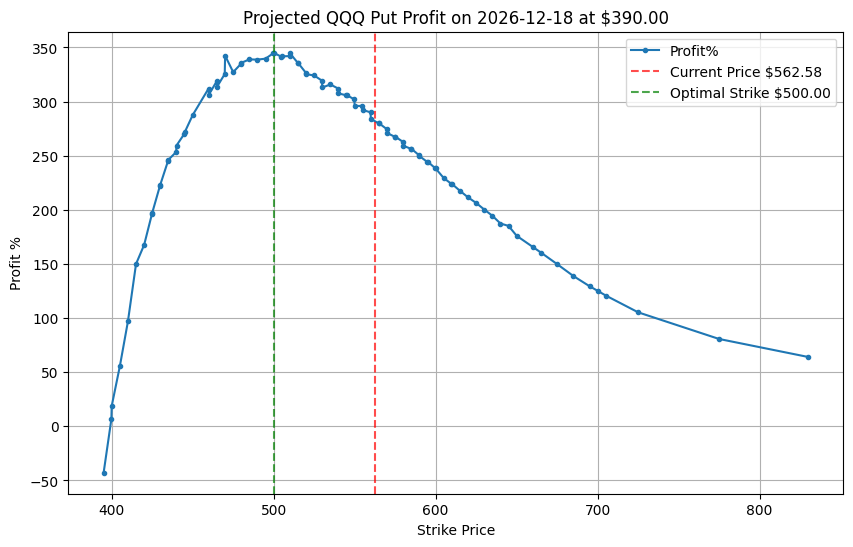

In [79]:

ax = df.plot(
  x='Strike', 
  y='Profit%', 
  kind='line', 
  marker='.', 
  title=f'Projected {symbol} Put Profit on {expiry} at ${target_price:.2f}', 
  xlabel='Strike Price', 
  ylabel='Profit %', 
  figsize=(10,6),
  grid=True)
ax.axvline(x=stock_price, color='red', linestyle='--', alpha=0.7, label=f'Current Price ${stock_price:.2f}')
ax.axvline(x=optimal_strike, color='green', linestyle='--', alpha=0.7, label=f'Optimal Strike ${optimal_strike:.2f}')
ax.legend()
